$$
\begin{aligned}
& \text{\textbf{Sets \& Parameters:}} \\
& N, \quad C \subset N, \quad K, \quad T = \{1,\dots,10\} \\
& d_{ij}, \quad Q, \quad h_i, \quad \rho_i, \quad I_i^0, \quad U_i \\ \\
& \text{\textbf{Decision Variables:}} \\
& x_{ijkt} \in \{0,1\}, \quad y_{kt} \in \{0,1\}, \quad z_{ikt} \in \{0,1\} \\
& I_{it} \ge 0, \quad q_{ikt} \ge 0 \\ \\
& \text{\textbf{Objective Function:}} \\
& \min \sum_{k,t} \sum_{i} \sum_{j \neq i} d_{ij} x_{ijkt} + \sum_{i,t} h_i I_{it} \\ \\
& \text{\textbf{Constraints:}} \\
& \text{(1)} \quad I_{it} = I_{i,t-1} + \sum_{k} q_{ikt} - \rho_i \quad \forall i \in C, \; \forall t \in T \\
& \text{(2)} \quad I_{it} \ge 0 \quad \forall i \in C, \; \forall t \in T \\
& \text{(3)} \quad I_{it} \le U_i \quad \forall i \in C, \; \forall t \in T \\
& \text{(4)} \quad q_{ikt} \le U_i z_{ikt} \quad \forall i,k,t \\
& \text{(5)} \quad \sum_{i} q_{ikt} \le Q y_{kt} \quad \forall k,t \\
& \text{(6)} \quad \sum_{j \in C} x_{0jkt} = y_{kt} \quad \forall k,t \\
& \text{(7)} \quad \sum_{i \in C} x_{i0kt} = y_{kt} \quad \forall k,t \\
& \text{(8)} \quad \sum_{j \neq i} x_{ijkt} = \sum_{j \neq i} x_{jikt} \quad \forall i,k,t \\
& \text{(9)} \quad z_{ikt} = \sum_{j \neq i} x_{jikt} \quad \forall i \in C, \; \forall k,t \\
& \text{(10)} \quad \text{sl}_{ikt} = \begin{cases} 1 - y_{kt} & i = 0 \\ 1 - z_{ikt} & i \in C \end{cases} \\
& \text{(11)} \quad x_{ijkt}, \; y_{kt}, \; z_{ikt} \in \{0,1\}, \quad I_{it}, \; q_{ikt} \ge 0
\end{aligned}
$$

In [1]:
import random
random.seed(44)

nodes = {
    0: (0, 0), 1: (2, 5), 2: (8, 3), 3: (5, 9), 4: (1, 7),
    5: (6, 4), 6: (9, 9), 7: (3, 1), 8: (7, 8), 9: (4, 4)
}

C = {i: nodes[i] for i in nodes.keys() if i!=0}

N = list(nodes.keys())

K = list(range(3))
Q = 15
T = [1,2,3,4,5,6,7,8,9,10]


h = {i: random.randint(1,5) for i in C.keys()}


rho = {i: random.randint(1,5) for i in C.keys()}
I0 = {i: random.randint(0,rho[i]*2) for i in C.keys()}

min_cap_customer, max_cap_customer= 20, 50
U   = {i: random.randint(min_cap_customer, max_cap_customer) for i in C}


In [2]:
import math
distance = {}
for i in N:
    for j in N:
        if i == j:
            distance[i,j] = 0
        else:
            xi,yi = nodes[i]
            xj,yj = nodes[j]
            dx, dy = xi-xj , yi-yj
            distance[i,j] = math.hypot(dx,dy)

In [3]:
from ortools.sat.python import cp_model

In [4]:
model = cp_model.CpModel()

In [5]:
y = {(k,t): model.NewBoolVar(f"y[{k}{t}]") for k in K for t in T}
z = {(i,k,t): model.NewBoolVar(f"z[{i},{k},{t}]") for i in C for k in K for t in T}
I = {(i,t): model.NewIntVar(0,U[i],f"I[{i},{t}]") for i in C for t in T}
q = {(i,k,t): model.NewIntVar(0,min(Q,U[i]),f"q[{i},{k}{t}]") for i in C for k in K for t in T}

In [6]:
x = {}
for k in K:
    for t in T:
        arcs = []
        for i in N:
            for j in N:
                if i != j:
                    x[i,j,k,t] = model.NewBoolVar(f"x[{i},{j},{k},{t}]")
                    arcs.append((i,j,x[i,j,k,t]))
                else:
                    if i == 0:
                        x[0,0,k,t] = y[k,t].Not()
                        pass
                    else: # i != 0
                        x[i,i,k,t] = z[i,k,t].Not()
                    arcs.append((i,i,x[i,i,k,t]))
        model.AddCircuit(arcs)

In [7]:
#Inventory dynamics
for i in C:
    #Starting inventory + deliveries − consumption.
    model.Add(I[i, 1] == I0[i] + sum(q[i,k,1] for k in K) - rho[i])
    for t in T[1:]:
        #Previous ending inventory + deliveries − consumption.
        model.Add(I[i,t] == I[i,t-1]+sum(q[i,k,t] for k in K) - rho[i])


In [8]:
# delivery only if visited
for i in C:
    for k in K:
        for t in T:
            model.Add(q[i,k,t]<=U[i]*z[i,k,t])

In [9]:
# vehicle capacity
for k in K:
    for t in T:
        model.Add(sum(q[i,k,t] for i in C) <= Q * y[k,t])

In [10]:
#cars sym break
for t in T:
    for k in K[:-1]:
        model.Add(y[k,t] >= y[k+1,t])
        
# for i in C:
#     for t in T:
#         model.Add(sum(z[i,k,t] for k in K) <= 1)

In [11]:
model.Minimize(
    sum(distance[i,j] * x[i,j,k,t]
        for i in N for j in N if i != j
        for k in K for t in T)
    + sum(h[i] * I[i,t]
          for i in C for t in T)
)

In [12]:
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 180
status = solver.solve(model)

In [13]:
"gap",(solver.ObjectiveValue() - solver.BestObjectiveBound()) / solver.BestObjectiveBound()

('gap', 0.15023201619832158)

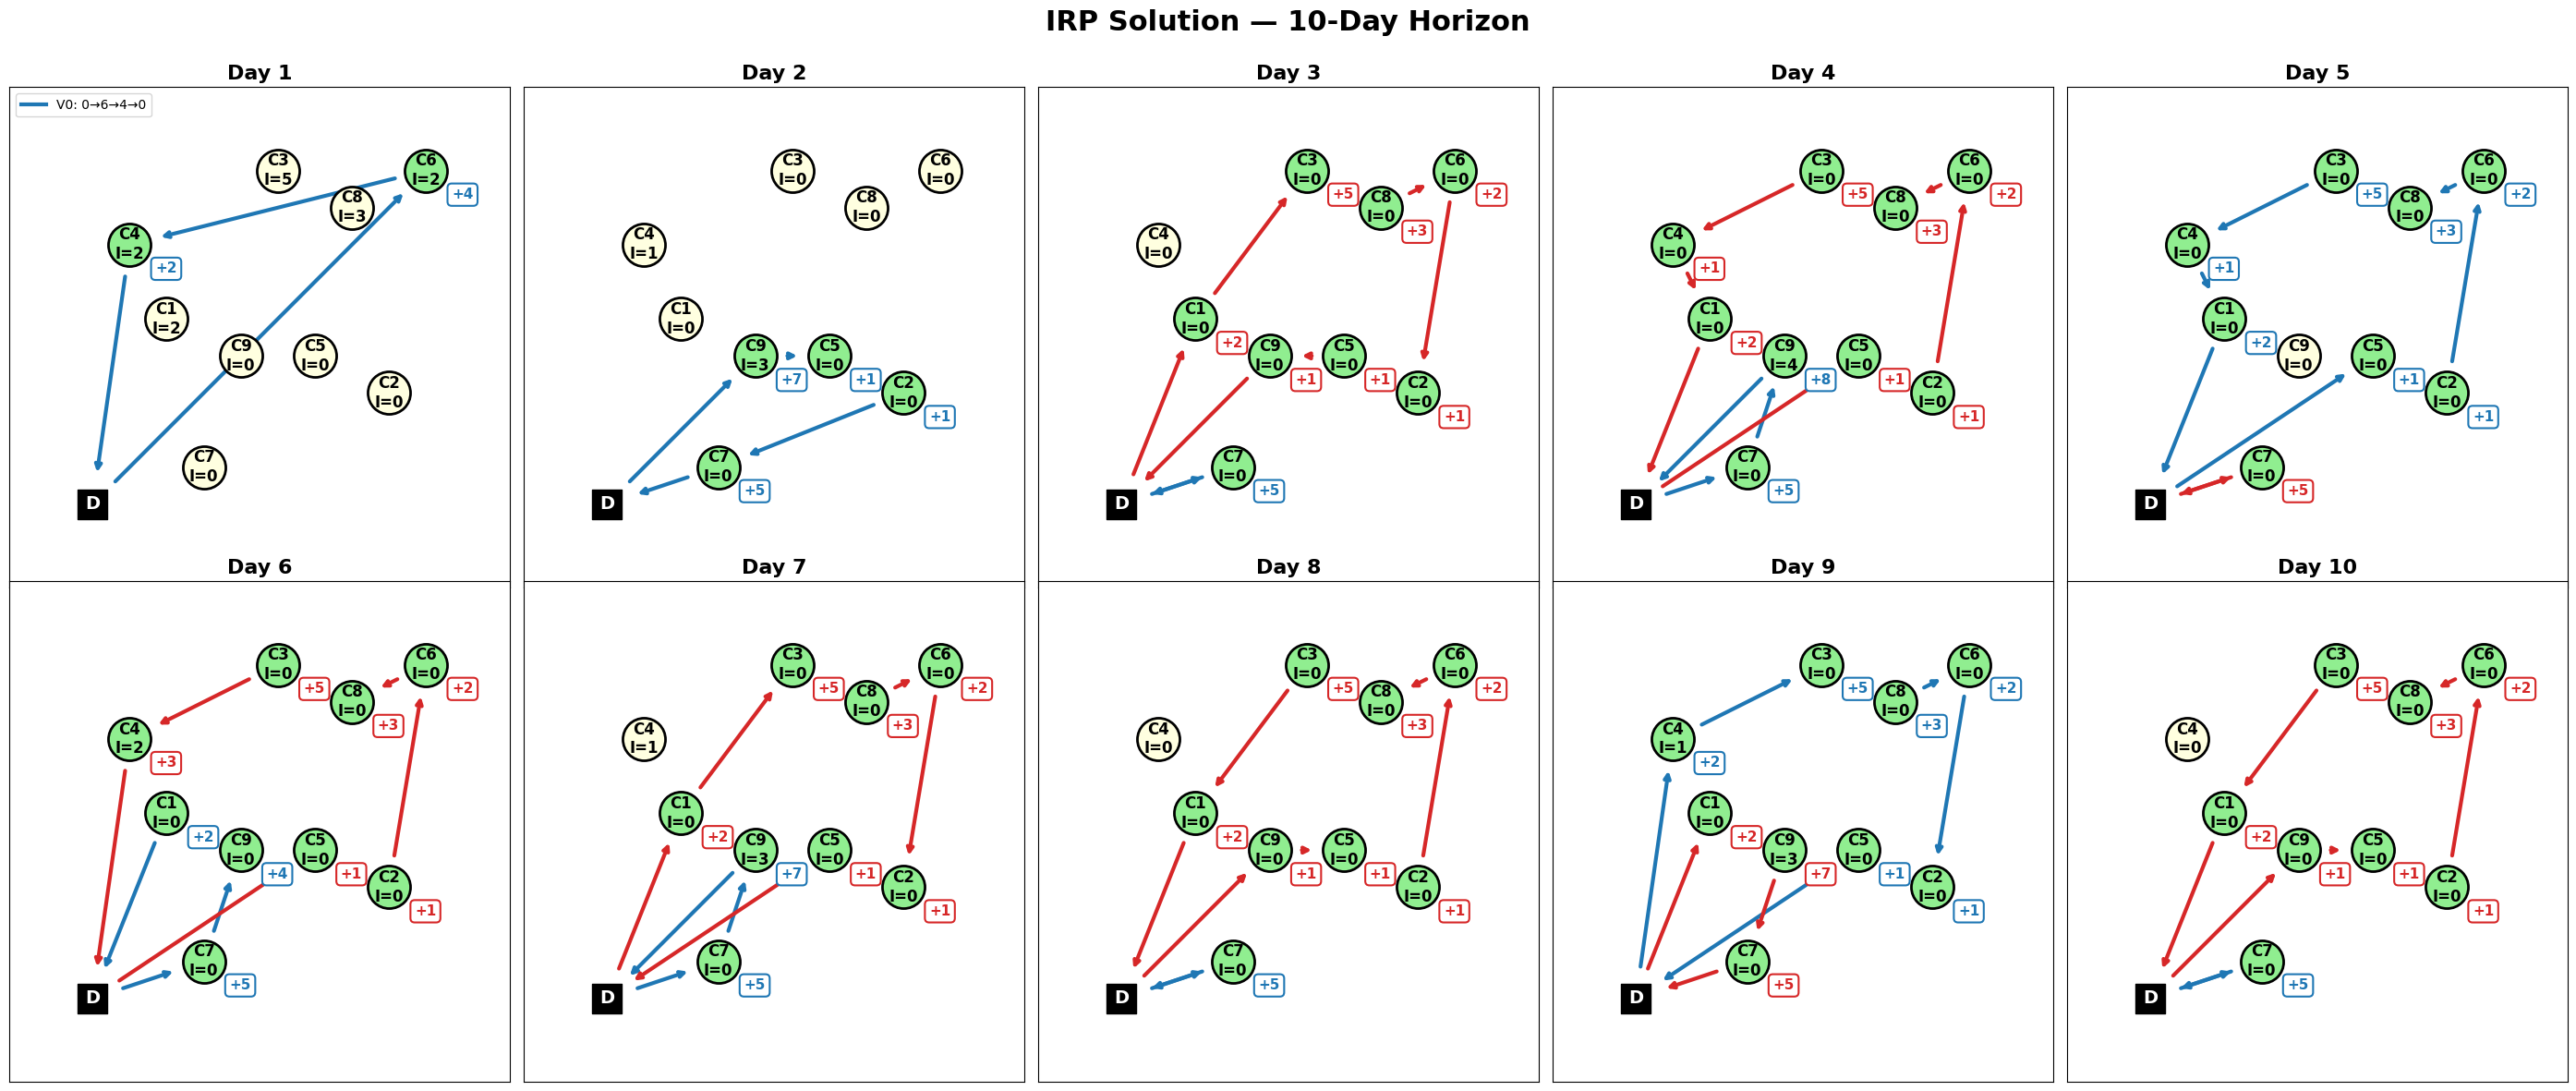

In [18]:
# Directly copy-pasted this part from AI

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_irp(solver, x, y, z, q, I, nodes, C, K, T, N, D=0):
    # bigger panels, fewer rows
    ncols = 5
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(28, 12))
    axes = axes.flatten()
    colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:orange', 'tab:purple']

    for idx, t in enumerate(T):
        ax = axes[idx]

        # depot
        ax.scatter(*nodes[D], c='black', s=500, marker='s', zorder=5)
        ax.annotate('D', nodes[D], fontsize=14, fontweight='bold', color='white',
                    ha='center', va='center', zorder=6)

        # customers with inventory label
        for i in C:
            inv = solver.Value(I[i, t])
            visited = any(solver.Value(z[i, k, t]) == 1 for k in K)
            color = 'lightgreen' if visited else 'lightyellow'
            ax.scatter(*nodes[i], c=color, s=1100, zorder=4,
                       edgecolors='black', linewidths=2)
            ax.annotate(f'C{i}\nI={inv}', nodes[i], fontsize=12, fontweight='bold',
                        ha='center', va='center', zorder=6)

        # routes for this day
        for k in K:
            if solver.Value(y[k, t]) == 0:
                continue
            color = colors[k % len(colors)]

            route = [D]
            cur = D
            while True:
                nxt = next((j for j in N if j != cur and solver.Value(x[cur, j, k, t]) == 1), None)
                if nxt is None or nxt == D:
                    route.append(D)
                    break
                route.append(nxt)
                cur = nxt

            for a, b in zip(route[:-1], route[1:]):
                ax.annotate('', xy=nodes[b], xytext=nodes[a],
                            arrowprops=dict(arrowstyle='->', color=color,
                                            lw=3, shrinkA=25, shrinkB=25),
                            zorder=3)

            # delivery quantities on visited customers
            for i in route[1:-1]:
                dq = solver.Value(q[i, k, t])
                if dq > 0:
                    ax.annotate(f'+{dq}', nodes[i], fontsize=11, fontweight='bold',
                                color=color,
                                xytext=(20, -22), textcoords='offset points',
                                bbox=dict(boxstyle='round,pad=0.3',
                                          fc='white', ec=color, lw=1.5),
                                zorder=7)

            route_str = '→'.join(map(str, route))
            ax.plot([], [], color=color, lw=3, label=f'V{k}: {route_str}')

        ax.set_title(f'Day {t}', fontsize=16, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal')
        ax.margins(0.25)
        if idx == 0:
            ax.legend(loc='upper left', fontsize=10)

    plt.suptitle('IRP Solution — 10-Day Horizon', fontsize=22, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


visualize_irp(solver, x, y, z, q, I, nodes, C, K, T, N, D=0)

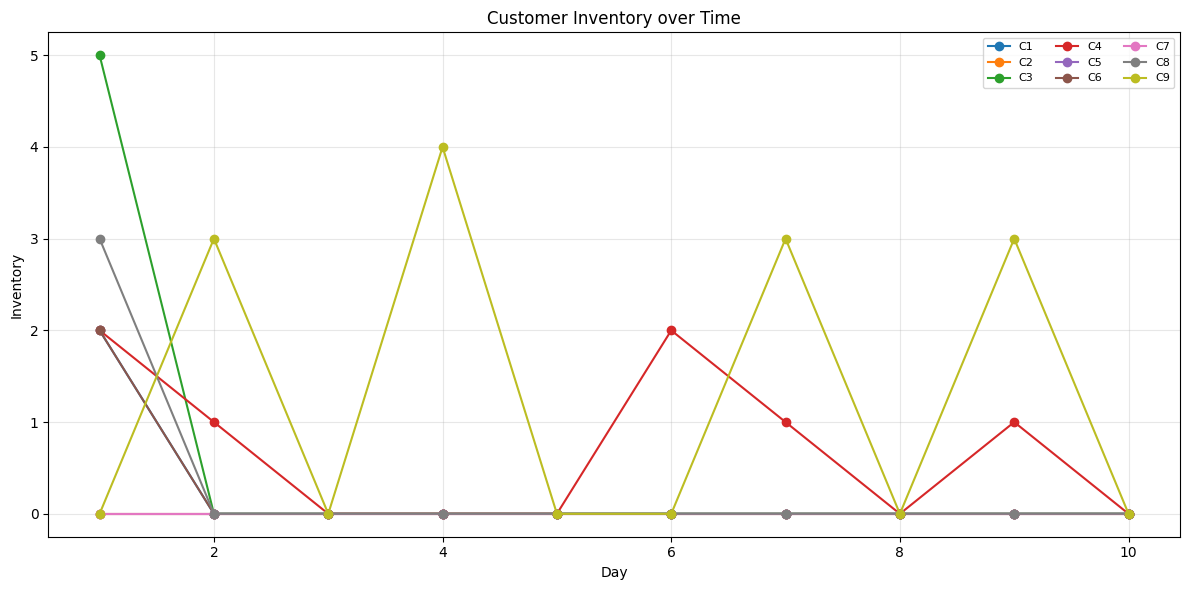

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
for i in C:
    inv = [solver.Value(I[i, t]) for t in T]
    ax.plot(T, inv, marker='o', label=f'C{i}')

ax.set_xlabel('Day')
ax.set_ylabel('Inventory')
ax.set_title('Customer Inventory over Time')
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()